# AgriML Model Evaluation and Accuracy Visualizations
Run the cells below to see the accuracy metrics (including K-Fold Cross Validation), confusion matrices, and model comparison graphs directly within this notebook.

In [4]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Ensure plots show inline in notebook
%matplotlib inline

# Add path for correct module imports
if os.path.abspath('.') not in sys.path:
    sys.path.insert(0, os.path.abspath('.'))

from services.crop_data import CROP_REQUIREMENTS
from ml.train_models import generate_synthetic_data, FEATURE_COLS

print('Libraries imported successfully.')

Libraries imported successfully.


### 1. Crop Recommendation Model Evaluation (with 5-Fold Cross Validation)

  Generated 2992 synthetic samples for 22 crops
Training Crop Models...
Random Forest   | Test Acc: 100.00% | CV Acc (K=5): 99.87% ± 0.16%
Extra Trees     | Test Acc: 100.00% | CV Acc (K=5): 99.93% ± 0.13%
XGBoost         | Test Acc: 99.83% | CV Acc (K=5): 99.60% ± 0.25%

Classification Report (Best Model): 
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        27
      Banana       1.00      1.00      1.00        27
   Blackgram       1.00      1.00      1.00        27
    Chickpea       1.00      1.00      1.00        27
     Coconut       1.00      1.00      1.00        27
      Coffee       1.00      1.00      1.00        27
      Cotton       1.00      1.00      1.00        28
      Grapes       1.00      1.00      1.00        28
        Jute       1.00      1.00      1.00        27
 Kidneybeans       1.00      1.00      1.00        27
      Lentil       1.00      1.00      1.00        28
       Maize       1.00      1.00      1.

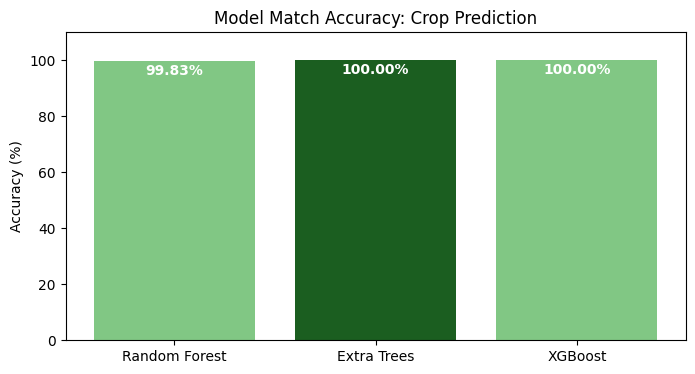

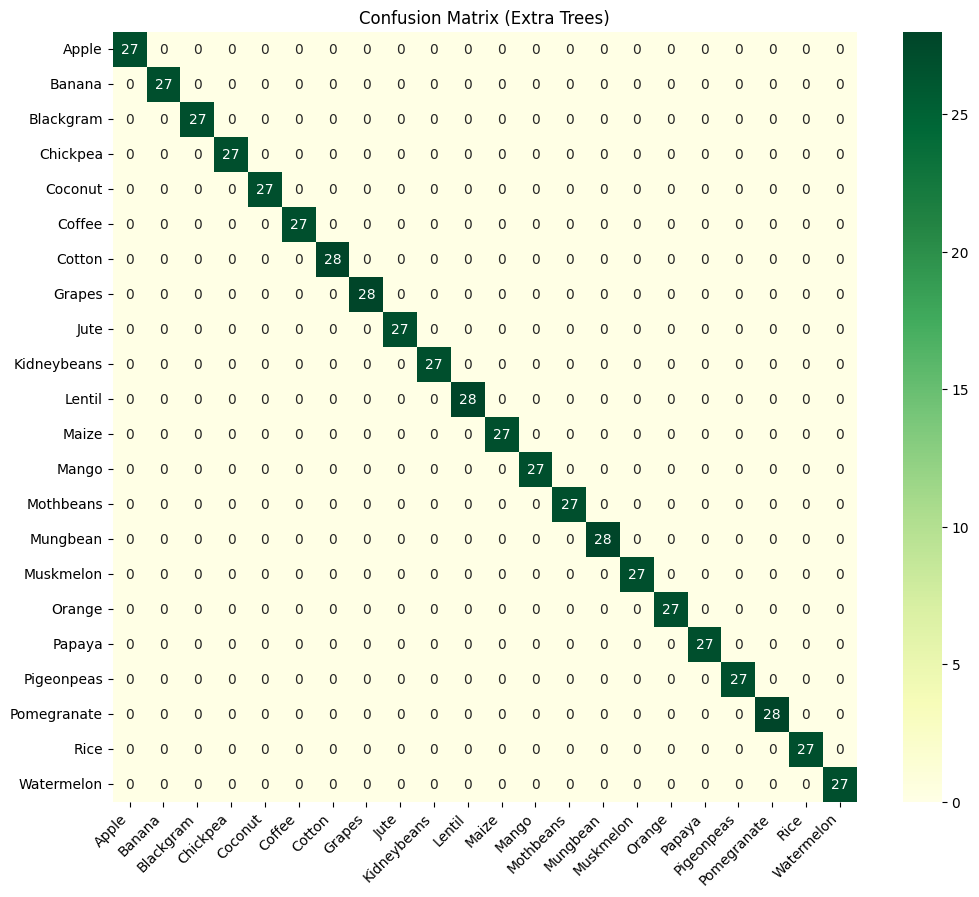

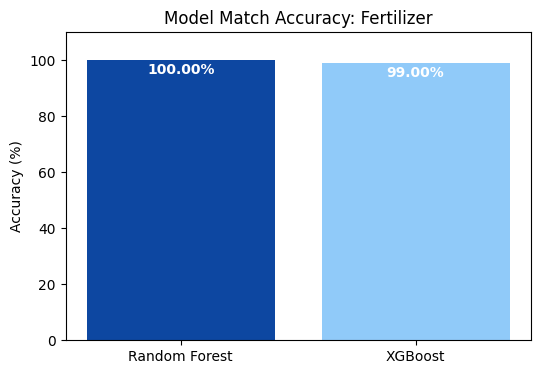

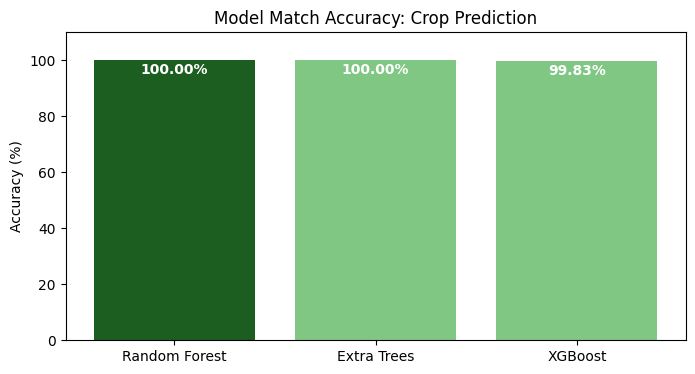

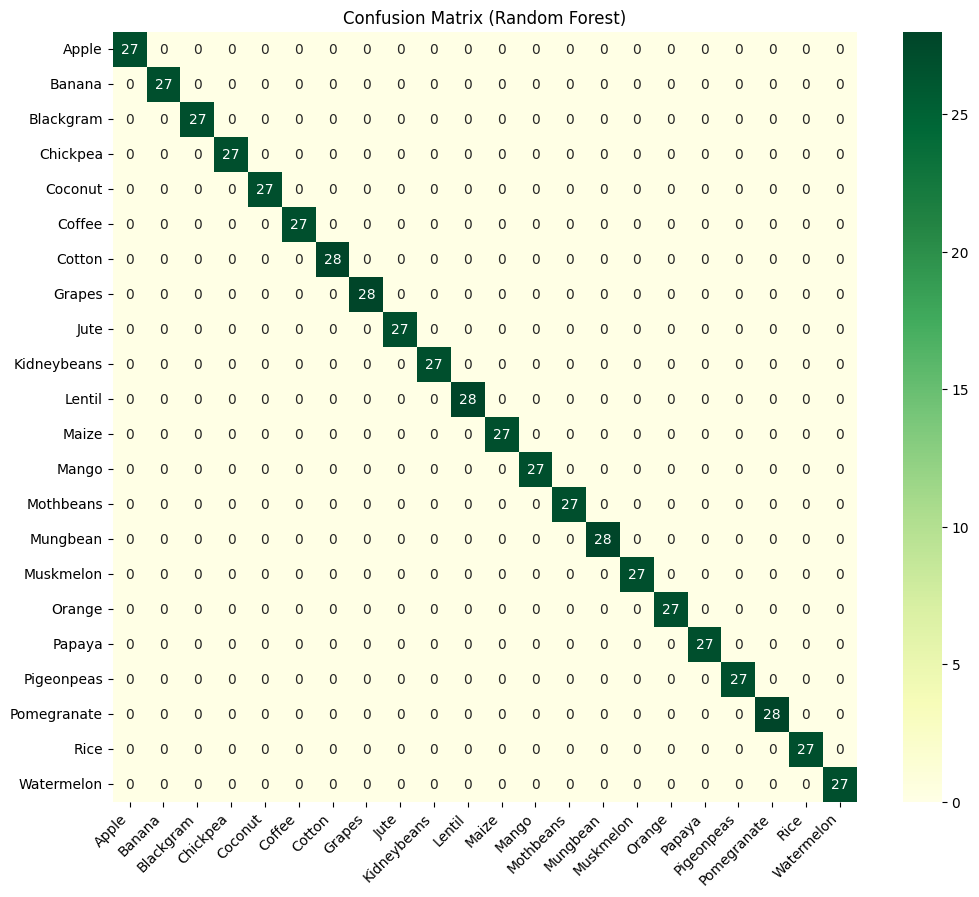

In [5]:
# Generate Dataset
df_crop = generate_synthetic_data(num_samples=3000)
X = df_crop[FEATURE_COLS].values
le = LabelEncoder()
y = le.fit_transform(df_crop["label"].values)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric="mlogloss", random_state=42, verbosity=0)
}

results = {}
best_model = None
best_acc = 0
best_name = ''

print("Training Crop Models...")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    # K-Fold Cross Validation (K=5)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    
    results[name] = acc * 100
    print(f'{name:<15} | Test Acc: {acc*100:.2f}% | CV Acc (K=5): {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
    
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_name = name

y_pred_best = best_model.predict(X_test)

print("\nClassification Report (Best Model): ")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# 1. Model Comparison Chart
plt.figure(figsize=(8, 4))
names = list(results.keys())
accs = list(results.values())
bars = plt.bar(names, accs, color=['#1b5e20' if n == best_name else '#81c784' for n in names])
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 5, f'{acc:.2f}%', ha='center', color='white', fontweight='bold')
plt.ylim(0, 110)
plt.title('Model Match Accuracy: Crop Prediction')
plt.ylabel('Accuracy (%)')
plt.show()

# 2. Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix ({best_name})')
plt.xticks(rotation=45, ha="right")
plt.show()

### 2. Fertilizer Recommendation Model Evaluation

Generating Fertilizer Dataset...
  Generated 2000 synthetic fertilizer samples
  Fertilizer classes: 8

Training Fertilizer Models...
Random Forest   | Test Acc: 100.00% | CV Acc: 99.85% ± 0.12%
XGBoost         | Test Acc: 99.75% | CV Acc: 99.55% ± 0.40%


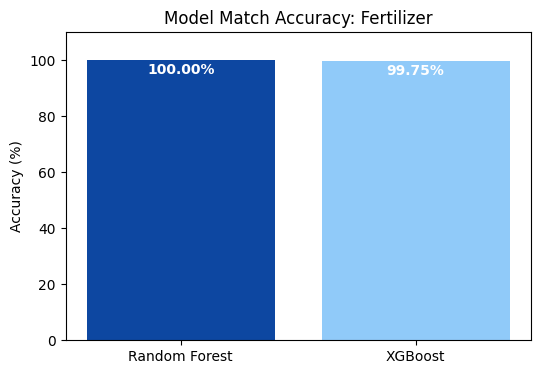

In [6]:
from ml.train_fertilizer import generate_fertilizer_data, FERTILIZER_FEATURES

print("Generating Fertilizer Dataset...")
df_fert = generate_fertilizer_data(num_samples=2000)
X_f = df_fert[FERTILIZER_FEATURES].values
le_f = LabelEncoder()
y_f = le_f.fit_transform(df_fert['fertilizer'].values)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f, y_f, test_size=0.2, random_state=42, stratify=y_f)

fert_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42, verbosity=0)
}

f_results = {}
print("\nTraining Fertilizer Models...")
for name, model in fert_models.items():
    model.fit(X_train_f, y_train_f)
    acc = accuracy_score(y_test_f, model.predict(X_test_f))
    # K-Fold cv=5
    cv_scores = cross_val_score(model, X_f, y_f, cv=5, scoring='accuracy')
    f_results[name] = acc * 100
    print(f'{name:<15} | Test Acc: {acc*100:.2f}% | CV Acc: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

plt.figure(figsize=(6, 4))
names_f = list(f_results.keys())
accs_f = list(f_results.values())
bars = plt.bar(names_f, accs_f, color=['#0d47a1', '#90caf9'])
for bar, acc in zip(bars, accs_f):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 5, f'{acc:.2f}%', ha='center', color='white', fontweight='bold')
plt.ylim(0, 110)
plt.title('Model Match Accuracy: Fertilizer')
plt.ylabel('Accuracy (%)')
plt.show()